# HNSCC Transcriptomic Subtyping via UMAP and Clustering

This notebook performs:

- Gene filtering based on expression and variance  
- PCA dimensionality reduction  
- UMAP embedding optimization  
- Multiple clustering approaches:
  - HDBSCAN  
  - k-means  
  - Hierarchical clustering  
  - Gaussian Mixture Models  

---

## Environment Setup

Before running this notebook, create the required **conda environment** using the provided `environment.yml` file. This ensures that all required package versions are installed and that the analysis is reproducible.

From the root directory of this repository, run:

```bash
conda env create -f environment.yml
```

Activate the environment:

```bash
conda activate transcriptomic_clustering
```

Then launch Jupyter:

```bash
jupyter notebook
```

Open the notebook and run it within this environment.

---

## Data

The expression matrix is stored in the repository as a compressed archive:

```
data/vst_transformed_raw.rar
```

The notebook automatically extracts this file using `unrar`, so **no manual download is required**.

When the notebook is executed, the archive will be extracted into the `data/` directory and the analysis will proceed using the extracted expression matrix.is will proceed using the extracted expression matrix.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import umap
import hdbscan
from adjustText import adjust_text
from scipy.stats import mannwhitneyu
from numpy import interp
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage


c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
!unrar x data/vst_transformed_raw.rar data/

In [3]:
dat = pd.read_csv("data/vst_transformed_raw.csv", index_col=0)

In [4]:
dat = dat.drop(columns=["SCC4", "SCC9"]) #We remove these samples as they are not part of the HNSCC map
dat.head()

,TCGA-D6-A4ZB-01A,TCGA-CV-7435-01A,TCGA-CR-7370-01A,TCGA-HL-7533-01A,TCGA-CR-7398-01A,TCGA-CV-A464-01A,TCGA-CV-7416-01A,TCGA-P3-A6T6-01A,TCGA-CV-A45R-01A,TCGA-CV-A463-01A,...,SRR14870161,SRR14870162,SRR14870163,SRR14870164,SRR14870165,SRR14870166,SRR14870167,SRR14870168,SRR14870169,SRR14870170
ENSG00000000003,10.267761,10.539015,11.016680,9.596099,11.148395,9.512046,10.029850,11.884178,11.089377,9.005419,...,9.902320,9.960071,11.090084,9.899203,10.339475,11.115345,10.099585,10.303318,10.725752,10.633962
ENSG00000000005,5.405018,5.840001,5.405018,5.405018,5.582931,5.751385,5.572622,5.676276,5.405018,5.630821,...,5.689456,5.405018,6.128751,5.656428,5.665247,5.694043,5.689621,5.712477,5.707167,5.696240
ENSG00000000419,10.565318,10.226914,9.597618,10.853493,10.536774,11.090972,10.938270,10.899845,10.944428,11.619870,...,10.740847,10.682330,10.557679,10.659491,10.731008,10.769516,10.615760,11.081013,10.886576,11.679685
ENSG00000000457,9.083519,9.052359,9.501318,9.291674,9.134990,8.772446,8.591737,9.139062,9.481076,8.933056,...,9.135417,9.137488,9.340241,9.146216,9.229122,9.317797,9.097962,8.443326,8.929853,8.548650
ENSG00000000460,8.549618,8.532673,9.708930,9.950473,9.595117,8.554930,8.596064,8.867276,8.295647,8.690790,...,8.894464,9.244185,8.535950,9.025654,9.188472,8.907699,9.199424,8.297861,8.490038,9.128448


In [5]:
#Expression-based filtering of the genes
expression_threshold = 1 
min_samples_threshold = 0.2 * dat.shape[1] 
variance_threshold = 1

df_filtered = dat[(dat > expression_threshold).sum(axis=1) > min_samples_threshold]

df_filtered = df_filtered[df_filtered.var(axis=1) > variance_threshold]
df_filtered.head()

,TCGA-D6-A4ZB-01A,TCGA-CV-7435-01A,TCGA-CR-7370-01A,TCGA-HL-7533-01A,TCGA-CR-7398-01A,TCGA-CV-A464-01A,TCGA-CV-7416-01A,TCGA-P3-A6T6-01A,TCGA-CV-A45R-01A,TCGA-CV-A463-01A,...,SRR14870161,SRR14870162,SRR14870163,SRR14870164,SRR14870165,SRR14870166,SRR14870167,SRR14870168,SRR14870169,SRR14870170
ENSG00000000971,10.353931,11.519050,10.894986,11.566365,10.468719,12.355215,11.700697,10.277984,12.946510,10.162578,...,11.263533,11.163863,11.864647,11.323848,11.345774,11.498163,11.385147,12.189277,9.102426,10.330203
ENSG00000001084,11.538089,12.048423,14.045133,10.446965,11.198781,10.896582,12.895217,13.176457,12.341478,12.309118,...,11.101509,11.280722,11.571329,10.563071,10.673520,11.767567,10.927922,11.864724,11.282094,10.411439
ENSG00000001561,7.954439,8.263213,8.002217,7.879260,7.491305,7.555224,7.304870,7.985456,7.897013,6.626692,...,7.180614,6.532748,8.352995,6.693761,6.643248,7.206131,9.397274,8.443326,6.582841,7.735930
ENSG00000001626,6.402023,6.132256,7.396588,5.600125,5.991419,5.405018,5.982087,7.713541,6.562060,5.405018,...,5.896102,5.994269,9.358380,5.905954,5.772542,5.903970,6.037367,6.566439,6.075821,5.405018
ENSG00000002587,8.233118,7.959693,7.726768,7.700821,8.244850,7.693133,8.583042,9.875233,8.950942,8.214898,...,10.021994,9.297990,9.812795,10.282608,10.404252,9.313917,8.623900,13.109673,10.941001,8.778936


In [6]:
df_filtered = df_filtered.T
df_filtered.shape

(727, 2896)

In [7]:
sns.set(rc={'figure.figsize':(6,6)})

In [8]:
test = df_filtered[df_filtered.columns]

In [9]:
pca = PCA(n_components=20, random_state=42) # Do not change the seed
test_pca = pca.fit_transform(test)

In [10]:
#different UMAP trials - change if you want to visualize other metrics
for j in [15,16,17]: 
    for k in range(9,12,1):
        for name in ['euclidean', 'manhattan', 'cosine']:
            red = umap.UMAP(metric = name, n_components=2,n_neighbors=j, min_dist=k/100.0, random_state=42, spread=5)
            embedding = red.fit_transform(np.array(test_pca))

            x = [each[0] for each in embedding]
            y = [each[1] for each in embedding]
            temp = pd.DataFrame(index = list(df_filtered.index))
            temp['x'] = x
            temp['y'] = y
            temp['name'] = temp.index

            sns.set(rc={'figure.figsize':(8,8)})
            sns.set_style("white")
            p1 = sns.scatterplot(x='x', y='y', data = temp, s=30)

            plt.savefig('umap_trials/' + str(j) + "_" + str(k) + "_" + name + '.png',dpi=300, bbox_inches='tight')
            temp.to_csv('umap_trials/' + str(j) + "_" + str(k) + "_" + name + '.csv')
            plt.clf()

c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\umap\umap_.py:1394: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\umap\umap_.py:1394: Ru

<Figure size 800x800 with 0 Axes>

#### We pick parameters n_neighbors = 16, min-distance = 0.11 and "manhattan" distance metric

In [ ]:
#Make sure 16_11_manhattan.csv exists or is run by the user
dat = pd.read_csv('umap_trials/16_11_manhattan.csv',index_col=0)
clu = dat[['x','y']].values

## DBSCAN clustering

In [22]:
## assign final / testing label here
labels = hdbscan.HDBSCAN(
    min_samples=4,
    min_cluster_size=40, 
    allow_single_cluster=True,
    metric = "euclidean"
).fit_predict(clu)

c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


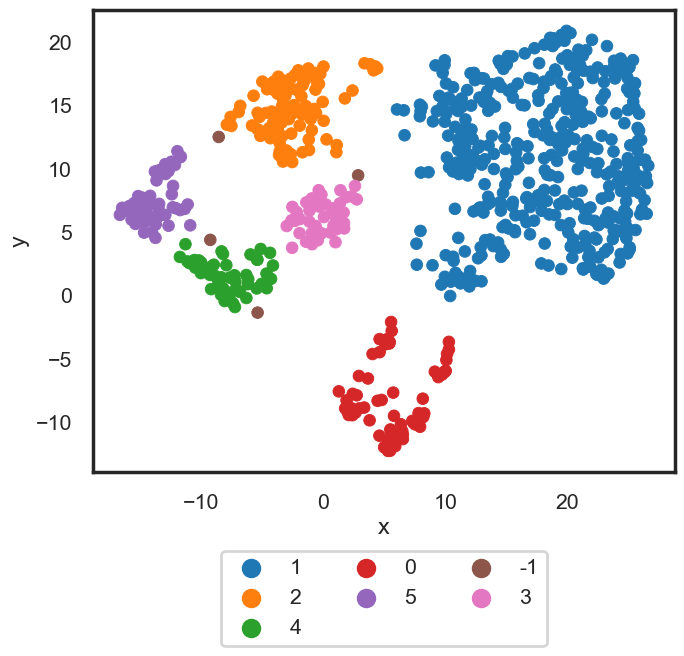

In [23]:
dat['label'] = labels
dat['label'] = [str(i) for i in dat['label']]
sns.set(rc={'figure.figsize':(7.5,6)})
sns.set_context("poster", font_scale=0.7)
sns.set_style("white")
scatter_plot = sns.scatterplot(data = dat, x = 'x', y = 'y', hue = 'label', s=70, alpha=1, edgecolor = None, palette='tab10')
scatter_plot.legend(loc='lower center', bbox_to_anchor=(0.5, -0.40), ncol=3)
plt.savefig('plots/16_11_man_dbscan.png', bbox_inches='tight', dpi=300)
plt.show()

In [24]:
dat.to_csv("results/16_11_man_dbscan.csv")

## K-means, heirachical clustering and GMM

In [25]:
dat = pd.read_csv('umap_trials/16_11_manhattan.csv', index_col=0)
clu = dat[['x', 'y']].values

In [26]:
inertia = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

K = range(2, 15)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(clu)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clu, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(clu, kmeans.labels_))
    calinski_harabasz_scores.append(calinski_harabasz_score(clu, kmeans.labels_))

c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\s

C:\Users\jvaz\AppData\Local\Temp\ipykernel_44568\2469082537.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, inertia, 'bo-', marker='o')


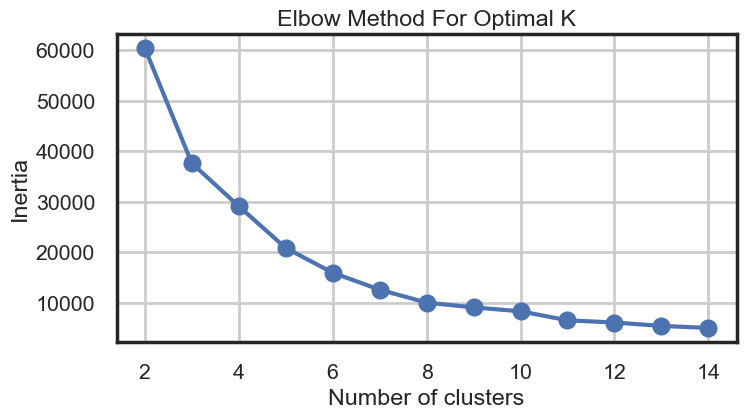

C:\Users\jvaz\AppData\Local\Temp\ipykernel_44568\2469082537.py:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, silhouette_scores, 'bo-', marker='o')


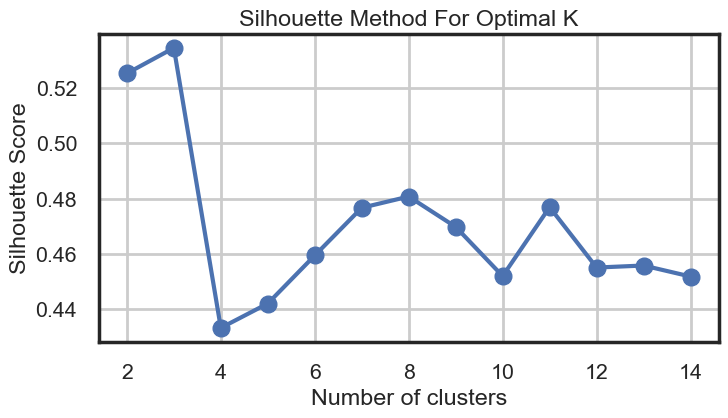

C:\Users\jvaz\AppData\Local\Temp\ipykernel_44568\2469082537.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, davies_bouldin_scores, 'bo-', marker='o')


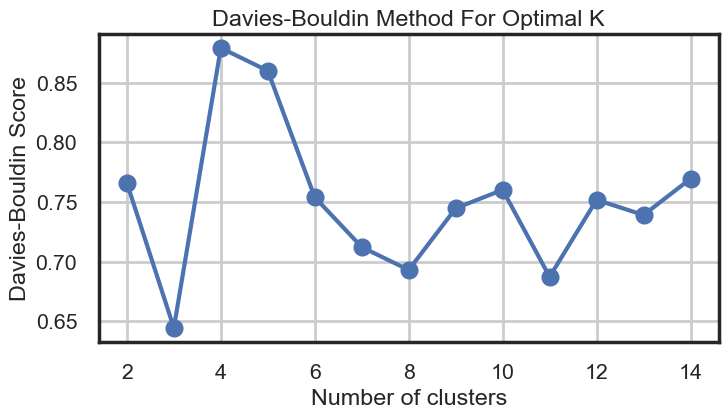

C:\Users\jvaz\AppData\Local\Temp\ipykernel_44568\2469082537.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, calinski_harabasz_scores, 'bo-', marker='o')


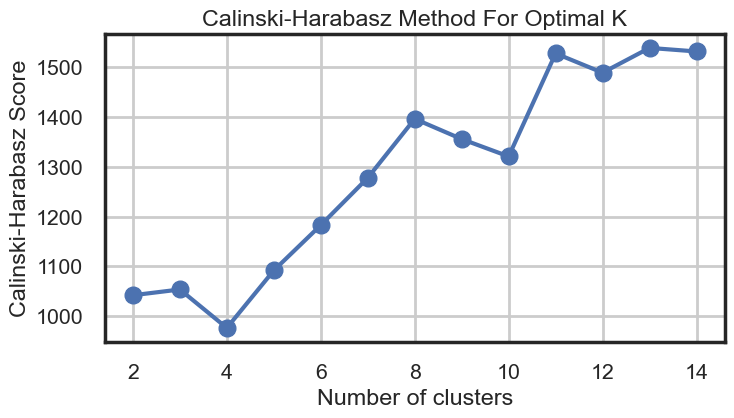

In [ ]:
# finding the optimal cluster number

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.savefig('plots/16_11_man_elbow.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_elbow.svg', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(K, silhouette_scores, 'bo-', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method For Optimal K')
plt.grid(True)
plt.savefig('plots/16_11_man_silhouette.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_silhouette.svg', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(K, davies_bouldin_scores, 'bo-', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Method For Optimal K')
plt.grid(True)
plt.savefig('plots/16_11_man_davies_bouldin.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_davies_bouldin.svg', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(K, calinski_harabasz_scores, 'bo-', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Method For Optimal K')
plt.grid(True)
plt.savefig('plots/16_11_man_calinski_harabasz.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_calinski_harabasz.svg', bbox_inches='tight')
plt.show()

In [28]:
# We find 9 clusters as optimal
optimal_clusters = 9
kmeans = KMeans(n_clusters=optimal_clusters,  random_state=42).fit(clu)
dat['kmeans_label'] = kmeans.labels_

c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [ ]:
dat.to_csv("results/16_11_man_kmeans.csv")

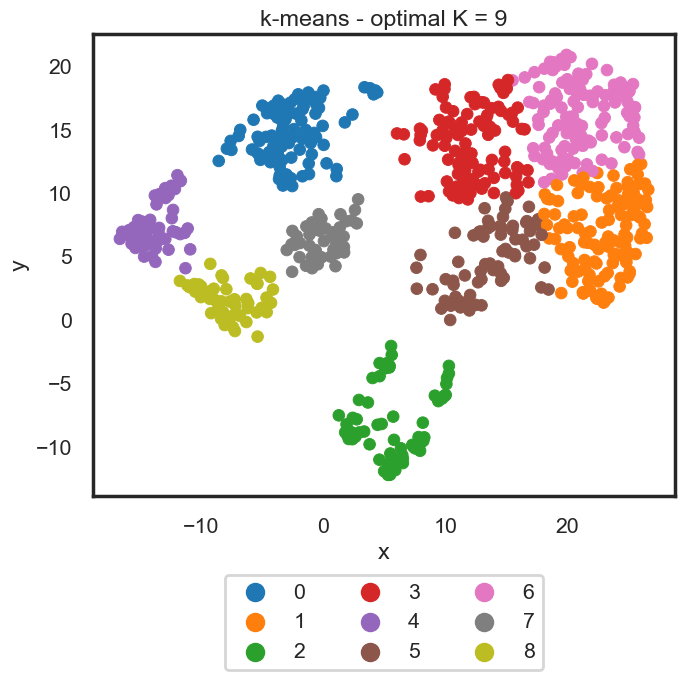

In [29]:
sns.set(rc={'figure.figsize':(7.5,6)})
sns.set_context("poster", font_scale=0.7)
sns.set_style("white")
scatter_kmeans = sns.scatterplot(data=dat, x='x', y='y', hue='kmeans_label', s=70, alpha=1, palette='tab10', edgecolor = None)
scatter_kmeans.legend(loc='lower center', bbox_to_anchor=(0.5, -0.40), ncol=3)
plt.title('k-means - optimal K = 9')
plt.savefig('plots/16_11_manhattan_kmeans.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_manhattan_kmeans.svg', bbox_inches='tight')
plt.show()

In [30]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
dat['hierarchical_label'] = agg_clustering.fit_predict(clu)

In [31]:
dat.to_csv("results/16_11_man_heirc_cls.csv")

In [32]:
dat.head()

,x,y,name,kmeans_label,hierarchical_label
TCGA-D6-A4ZB-01A,20.908136,3.808990,TCGA-D6-A4ZB-01A,1,2
TCGA-CV-7435-01A,6.672261,12.659571,TCGA-CV-7435-01A,3,1
TCGA-CR-7370-01A,-4.085498,13.681855,TCGA-CR-7370-01A,0,3
TCGA-HL-7533-01A,24.703230,18.327238,TCGA-HL-7533-01A,6,0
TCGA-CR-7398-01A,-4.324299,12.424221,TCGA-CR-7398-01A,0,3


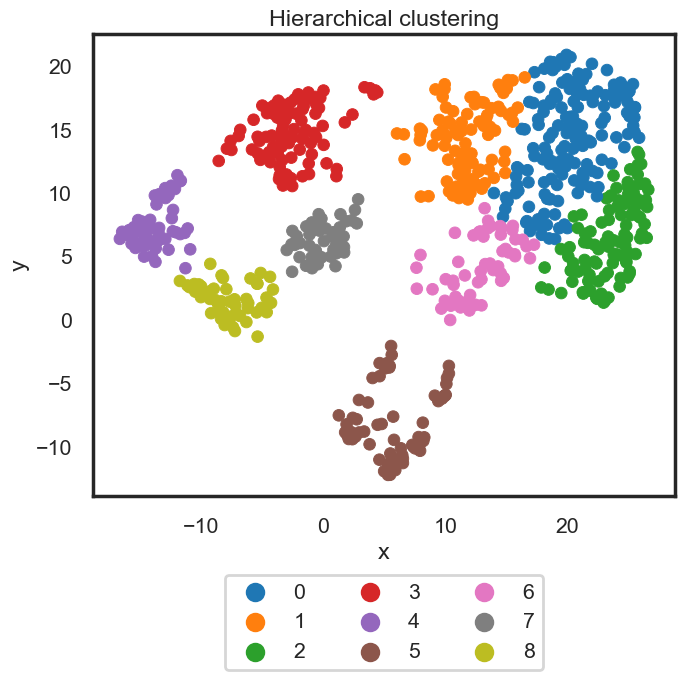

In [33]:
sns.set(rc={'figure.figsize':(7.5,6)})
sns.set_context("poster", font_scale=0.7)
sns.set_style("white")
scatter_hierarchical = sns.scatterplot(data=dat, x='x', y='y', hue='hierarchical_label', s=70, alpha=1, palette='tab10', edgecolor = None)
scatter_hierarchical.legend(loc='lower center', bbox_to_anchor=(0.5, -0.40), ncol=3)
plt.title('Hierarchical clustering')
plt.savefig('plots/16_11_man_heirc_cls.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_heirc_cls.svg', bbox_inches='tight')
plt.show()

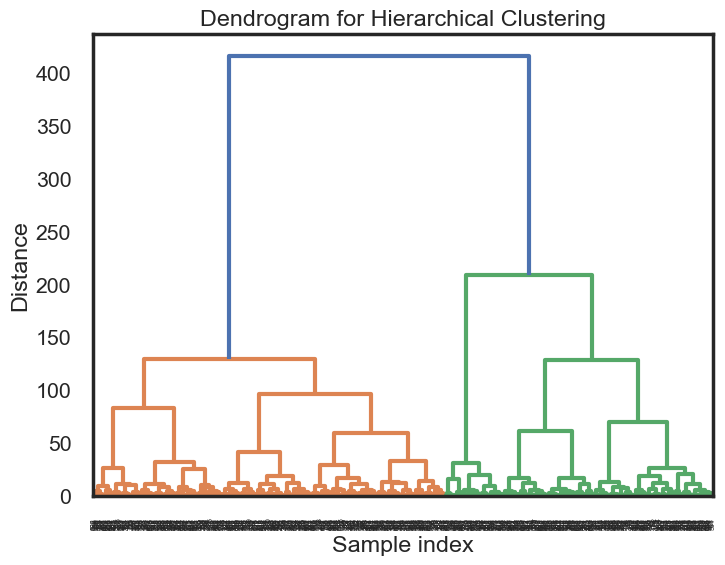

In [36]:
plt.figure(figsize=(8, 6))
Z = linkage(clu, 'ward')
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('plots/16_11_man_dendrogram.png', bbox_inches='tight', dpi=300)
plt.show()

In [37]:
dat = pd.read_csv('UMAP_trials/16_11_manhattan.csv', index_col=0)
clu = dat[['x', 'y']].values

In [38]:
n_components = np.arange(1, 20)
bic_scores = []

In [39]:
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(clu)
    bic_scores.append(gmm.bic(clu))

c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\s

C:\Users\jvaz\AppData\Local\Temp\ipykernel_44568\2899923160.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(n_components, bic_scores, 'bo-', marker='o')


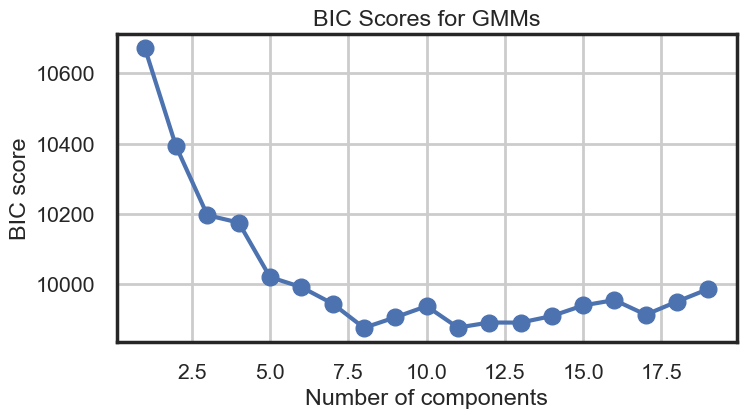

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(n_components, bic_scores, 'bo-', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC score')
plt.title('BIC Scores for GMMs')
plt.grid(True)
plt.savefig('plots/16_11_man_gmm_bic_plot.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_gmm_bic_plot.svg', bbox_inches='tight')
plt.show()

In [41]:
# set optimal component number here based on BIC scores
optimal_components = 6

gmm = GaussianMixture(n_components=optimal_components, random_state=0)
dat['gmm_label'] = gmm.fit_predict(clu)


c:\Users\jvaz\AppData\Local\miniconda3\envs\gen\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [42]:
dat.to_csv("results/16_11_man_gmm.csv")

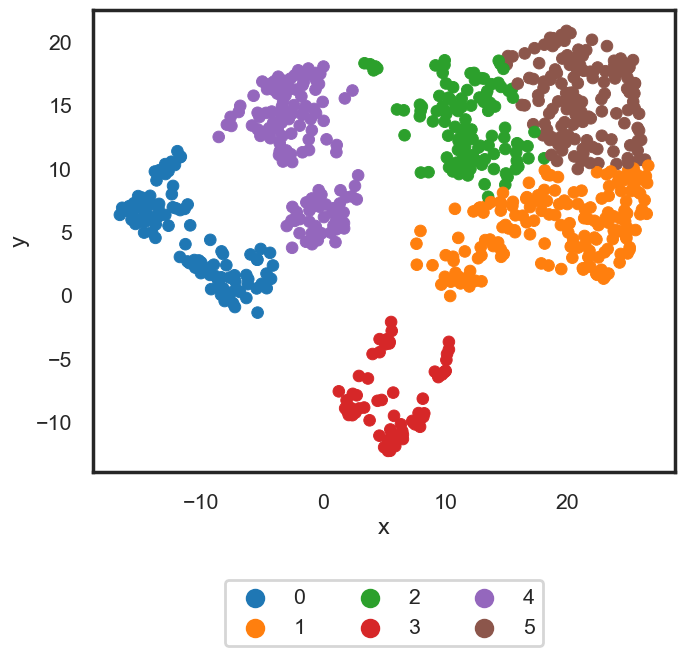

In [43]:
sns.set(rc={'figure.figsize':(7.5,6)})
sns.set_context("poster", font_scale=0.7)
sns.set_style("white")
scatter_gmm = sns.scatterplot(data=dat, x='x', y='y', hue='gmm_label', s=70, alpha=1, palette='tab10', edgecolor = None)
scatter_gmm.legend(loc='lower center', bbox_to_anchor=(0.5, -0.40), ncol=3)
plt.savefig('plots/16_11_man_gmm_clustering.png', bbox_inches='tight', dpi=300)
plt.savefig('plots/16_11_man_gmm_clustering.svg', bbox_inches='tight')
plt.show()